# Decision Tree Model — Iris Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('iris-data-clean.csv')
df.head()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,class
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [3]:
df['class'] = df['class'].map({'Setosa': 0, 'Versicolor': 1, 'Virginica': 2})
df.head()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Preprocess the data

In [4]:
X = df[['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm']]
y = df['class']

### Build the Decision Tree Model

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [6]:
# No max_depth — tree grows until leaves are pure
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

### Evaluate the model

In [7]:
y_pred = dt.predict(X_test)
print(f'Accuracy (no depth limit): {accuracy_score(y_test, y_pred):.4f}')

Accuracy (no depth limit): 0.8919


### Visualize the Decision Tree

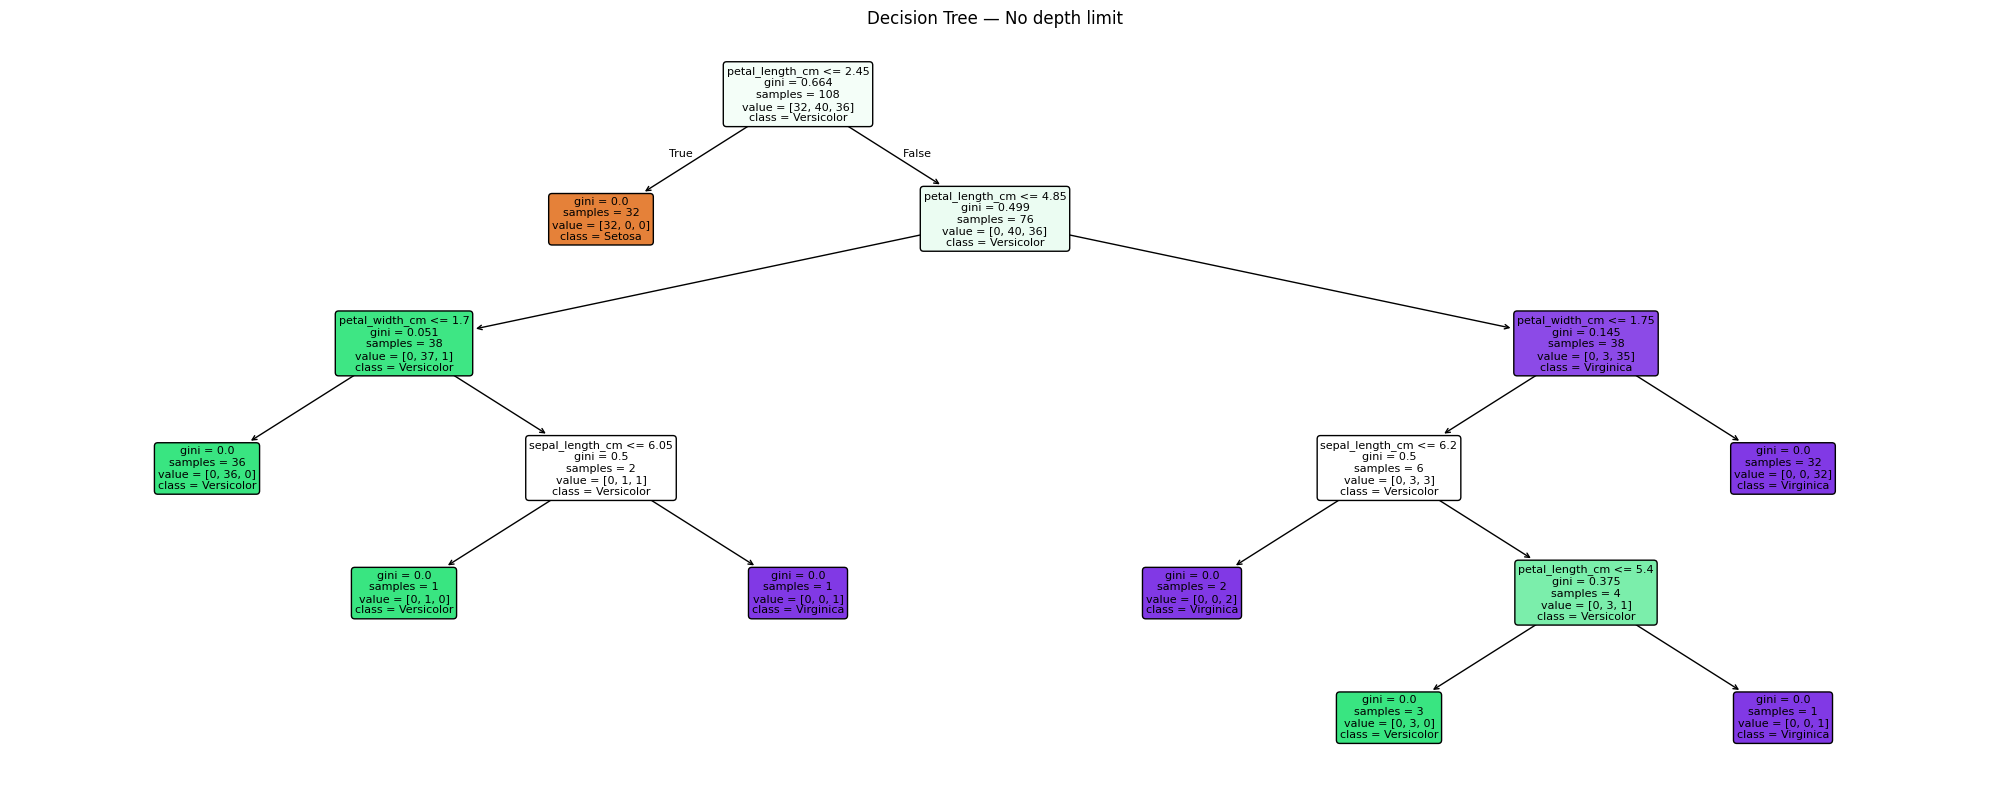

In [8]:
plt.figure(figsize=(20, 8))
plot_tree(dt, feature_names=X.columns,
          class_names=['Setosa', 'Versicolor', 'Virginica'],
          filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree — No depth limit')
plt.tight_layout()
plt.show()

---
## 2) Set the level of depth to 3. Send some data for prediction.

In [9]:
dt3 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt3.fit(X_train, y_train)

y_pred3 = dt3.predict(X_test)
print(f'Accuracy (max_depth=3): {accuracy_score(y_test, y_pred3):.4f}')

Accuracy (max_depth=3): 0.9189


In [10]:
# Predict a new sample
sample = pd.DataFrame({'sepal_length_cm': [6.4], 'sepal_width_cm': [2.9],
                        'petal_length_cm': [4.3], 'petal_width_cm': [1.3]})
pred_label = dt3.predict(sample)[0]
print('Prediction:', ['Setosa', 'Versicolor', 'Virginica'][pred_label])

Prediction: Versicolor


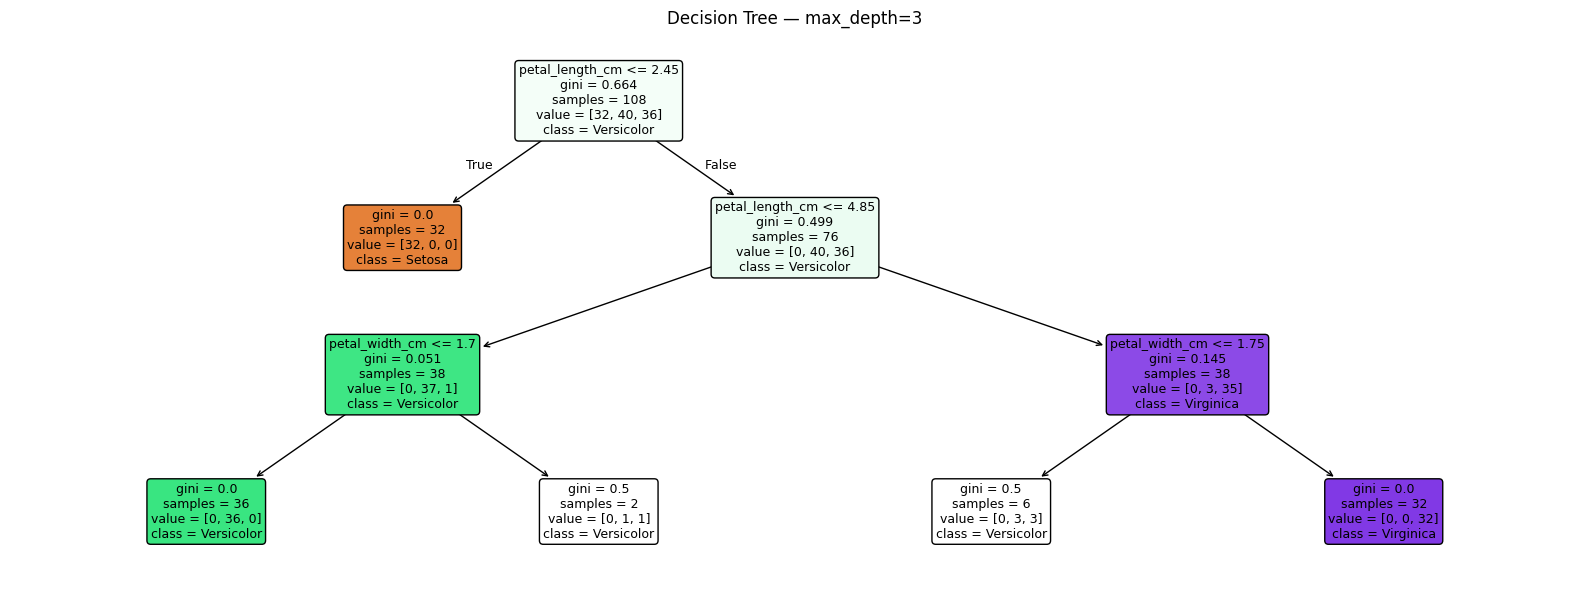

In [11]:
plt.figure(figsize=(16, 6))
plot_tree(dt3, feature_names=X.columns,
          class_names=['Setosa', 'Versicolor', 'Virginica'],
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree — max_depth=3')
plt.tight_layout()
plt.show()

---
## 3) Set the level of depth to 1. Send some data for prediction. What is the outcome? Describe your reason.

In [12]:
dt1 = DecisionTreeClassifier(max_depth=1, random_state=42)
dt1.fit(X_train, y_train)

y_pred1 = dt1.predict(X_test)
print(f'Accuracy (max_depth=1): {accuracy_score(y_test, y_pred1):.4f}')
print('Predicted classes:', sorted(set(y_pred1)))

Accuracy (max_depth=1): 0.6216
Predicted classes: [np.int64(0), np.int64(1)]


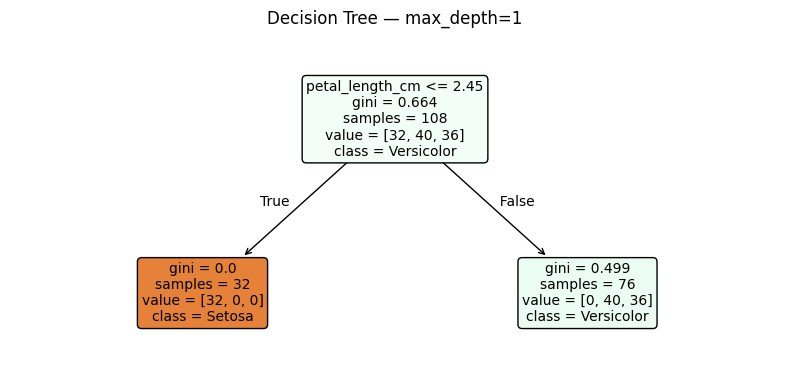

In [13]:
plt.figure(figsize=(8, 4))
plot_tree(dt1, feature_names=X.columns,
          class_names=['Setosa', 'Versicolor', 'Virginica'],
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree — max_depth=1')
plt.tight_layout()
plt.show()

### Answer

With `max_depth=1` the tree can make only **one split** on the entire dataset. It finds the single best feature threshold (petal length) that separates the data, which cleanly isolates Setosa but cannot distinguish Versicolor from Virginica.

As a result:
- The model predicts only **two classes** — it never predicts the third class at all.
- Accuracy drops significantly compared to the deeper trees.

This is **underfitting**: the model is too simple to capture the structure of a 3-class problem. Increasing `max_depth` allows more splits and better separation of all three classes.